In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
import torch

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [4]:
seed = 42

initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
gamma = 1
alpha=0.001
mu=0
big_phi = 0.1

In [5]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)
# intensity =  np.array([psi + phi, psi + phi])  # intensity for PoissonArrivalModel

psi value: 14.872283180889763


In [6]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [7]:
as_env = get_as_env()

In [8]:
as_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


In [9]:
def plot_fad_and_filtered(env: gym.Env, agent: Agent, seed: int = None):
    """
    Plot fad (2nd component of midprice_model) and filtered fad (3rd component).
    """
    timestamps = get_timestamps(env)
    observations, actions, rewards = generate_trajectory(env, agent, seed)

    # Extract fad and filtered fad
    fad = observations[:, 4, :]           # index 4 = second component of midprice_model
    filtered_fad = observations[:, 5, :]  # index 5 = third component

    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(env.num_trajectories):
        ax.plot(
            timestamps,
            fad[i, :],
            label=f"Fad traj {i}" if env.num_trajectories > 1 else "Fad",
            color="r",
            alpha=0.7,
        )
        ax.plot(
            timestamps,
            filtered_fad[i, :],
            label=f"Filtered Fad traj {i}" if env.num_trajectories > 1 else "Filtered Fad",
            color="b",
            linestyle="--",
            alpha=0.7,
        )

    ax.set_title("Fad vs Filtered Fad")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    plt.tight_layout()
    plt.show()



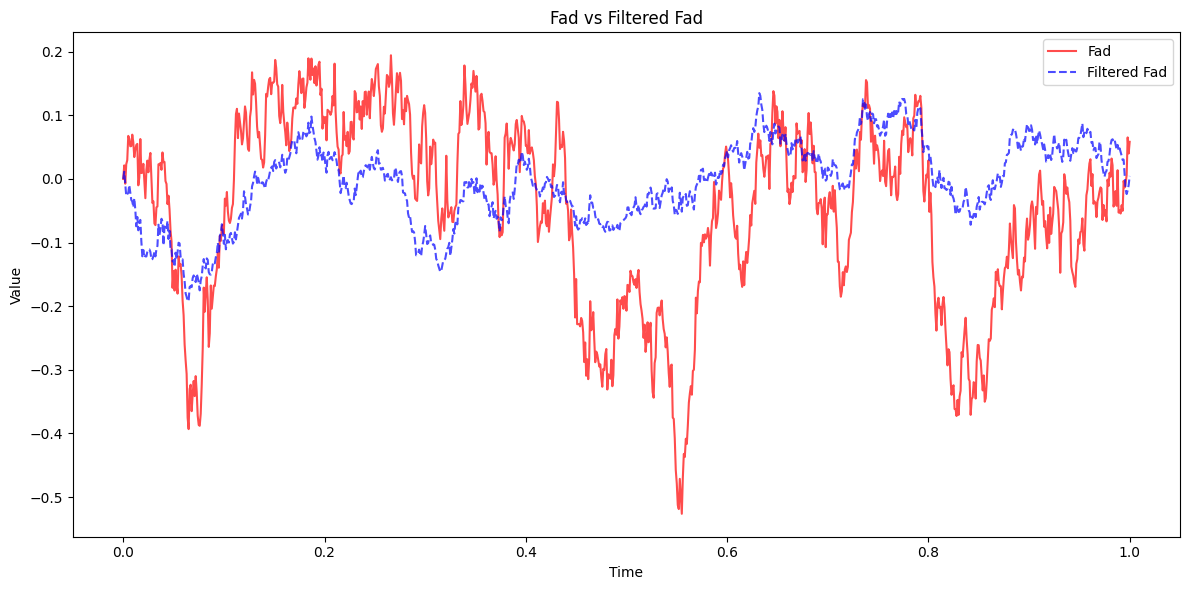

In [10]:
plot_fad_and_filtered(env=as_env, agent=as_agent)

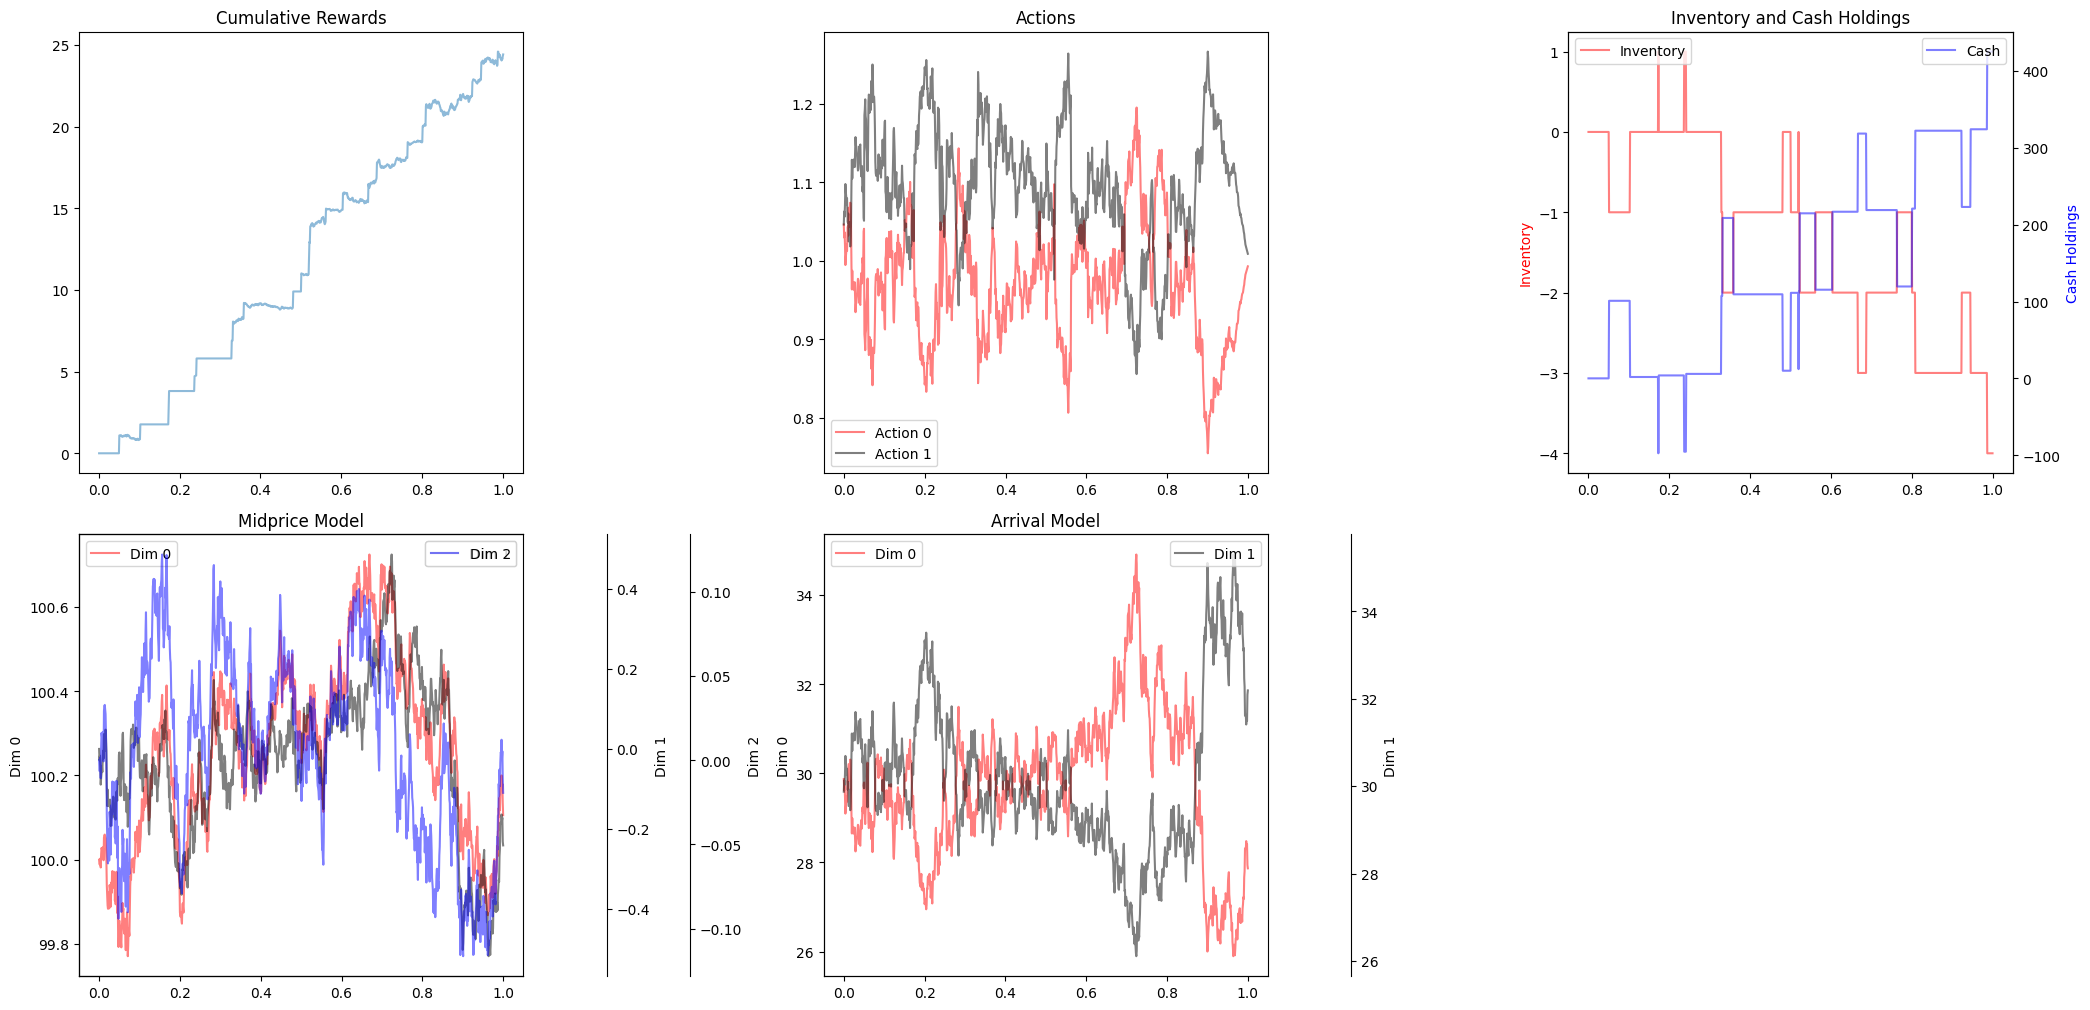

In [11]:
plot_trajectory_extended(as_env, as_agent)

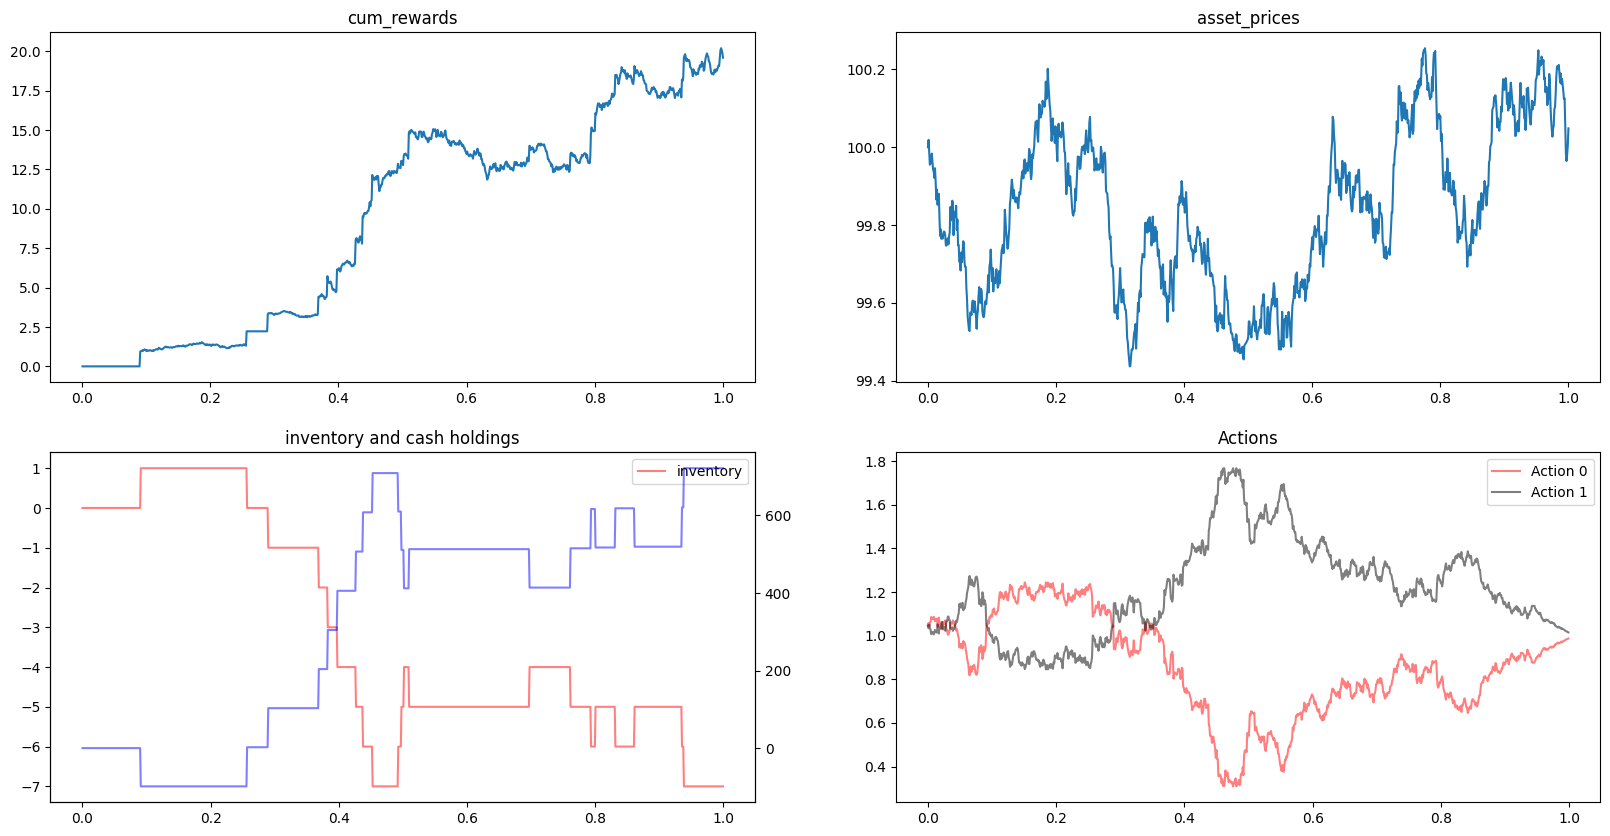

In [12]:
plot_trajectory(as_env, as_agent, seed = seed)

In [13]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [14]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [15]:
initial_fads = 0
TrueMean= initial_fads * np.exp(-eta * terminal_time)
fad_trajectories = observations[:, FADS_INDEX, :]  # shape: (num_trajectories, n_steps+1)

simulated_mean = np.mean(fad_trajectories, axis=0)

print("Simulated mean of the fad at terminal time:", simulated_mean)
print("True mean of the fad at terminal time:", TrueMean)

Simulated mean of the fad at terminal time: [ 0.         -0.00042075 -0.00087728 ...  0.00523769  0.0044405
  0.00422326]
True mean of the fad at terminal time: 0.0


In [16]:
initial_fads = 0
TrueMean= initial_fads * np.exp(-eta * terminal_time)
filtered_fad_trajectories = observations[:, FILTERED_FADS_INDEX, :]  # shape: (num_trajectories, n_steps+1)

simulated_mean = np.mean(filtered_fad_trajectories, axis=0)

print("Simulated mean of the fad at terminal time:", simulated_mean)
print("True mean of the fad at terminal time:", TrueMean)

Simulated mean of the fad at terminal time: [ 0.         -0.00014323 -0.00015657 ... -0.00147033 -0.0012499
 -0.00163963]
True mean of the fad at terminal time: 0.0


In [17]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [18]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.262921,4.883461,-0.093,3.100702


### Parameters

In [19]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion_values = [0.3, 0.6, 0.9]
# p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10.0
phi = 15
k = 1
gamma = 1
alpha=0.001
mu=0
big_phi=0.1

In [20]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi_values = {q: compute_psi(q) for q in fads_proportion_values}

print("psi values:", psi_values)

psi values: {0.3: 14.967970890292623, 0.6: 14.872283180889763, 0.9: 14.71412778506946}


In [21]:

def get_as_env(num_trajectories:int = 1, fads_proportion:float=0.6, psi:float=15):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [22]:
results_dict = {}
actions_dict = {}
for fads_proportion in fads_proportion_values:
    # Create environment with single trajectory
    env = get_as_env(num_trajectories=1, 
                     fads_proportion=fads_proportion, 
                     psi=psi_values[fads_proportion])

    # Create agent
    agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=env)

    # Generate single trajectory
    observations, actions, rewards = generate_trajectory(env, agent)
    
    # Store results
    results_dict[fads_proportion] = dict(
        obs=observations,
        actions=actions,
        rewards=rewards
    )

✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points


In [23]:
def plot_fad_and_filtered_subplots(results_dict, fads_proportions):
    """
    Plot fad vs filtered fad trajectories for multiple fads_proportion values.

    Parameters
    ----------
    results_dict : dict
        Dictionary containing observations for each fads_proportion
    fads_proportions : list
        List of fads_proportion values to plot
    """
    # Create figure with 3 subplots horizontally
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    # Get timestamps (assuming same length for all)
    timestamps = get_timestamps(env)

    for ax, fads_prop in zip(axes, fads_proportions):
        # Get data for this proportion
        observations = results_dict[fads_prop]['obs']
        
        # Extract fad and filtered fad
        fad = observations[:, 4, :]           
        filtered_fad = observations[:, 5, :]  

        # Plot
        ax.plot(
            timestamps,
            fad[0, :],
            label="Fad",
            color="r",
            alpha=0.7,
        )
        ax.plot(
            timestamps,
            filtered_fad[0, :],
            label="Filtered Fad",
            color="b",
            linestyle="--",
            alpha=0.7,
        )

        ax.set_title(f"Fads Proportion = {fads_prop}")
        ax.set_xlabel("Time")
        if ax == axes[0]: 
            ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    plt.suptitle("Fad vs Filtered Fad Comparison Across Different Fads Proportions", fontsize=14)
    plt.tight_layout()
    plt.show()

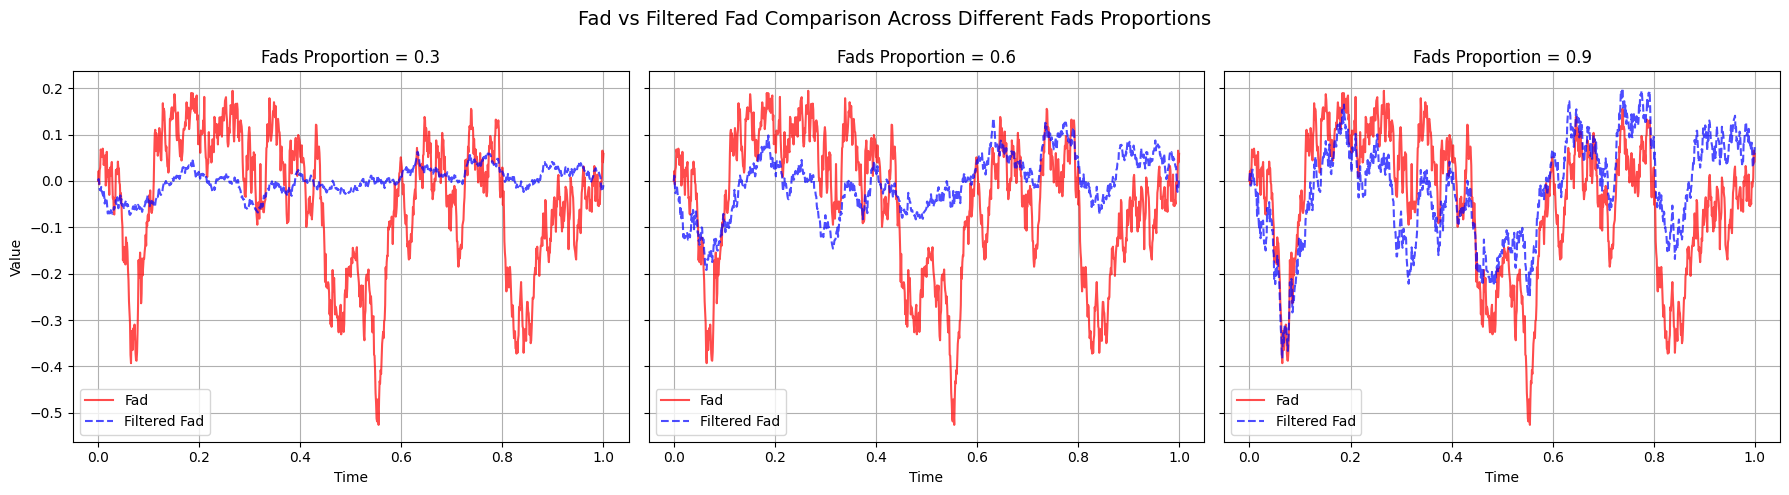

In [24]:
plot_fad_and_filtered_subplots(results_dict, fads_proportion_values)